In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from scipy.optimize import linear_sum_assignment


# Загрузка Mushroom
from sklearn.datasets import fetch_openml
data = fetch_openml('mushroom', version=1, as_frame=True)
df = data.frame
df


,cap-shape,cap-surface,cap-color,bruises%3F,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,o,o,p,o,o,p,b,c,l,e
8120,x,s,n,f,n,a,c,b,y,e,...,o,o,p,n,o,p,b,v,l,e
8121,f,s,n,f,n,a,c,b,n,e,...,o,o,p,o,o,p,b,c,l,e
8122,k,y,n,f,y,f,c,n,b,t,...,w,w,p,w,o,e,w,v,l,p


In [80]:
X_raw = df.drop('class', axis=1)
y_true = (df['class'] == 'p').astype(int)

# Вспомогательное



In [ ]:
def hamming_distance(x, y):
     #Расстояние между двумя векторами категорий
    return np.sum(x != y)

def compute_dissimilarity_matrix(X, centroids):
    #Матрица расстояний между всеми точками X и центроидами
    n = X.shape[0]
    k = centroids.shape[0]
    D = np.zeros((n, k))
    for i in range(n):
        for j in range(k):
            D[i, j] = hamming_distance(X[i], centroids[j])
    return D

def assign_clusters(X, centroids):
    #Назначение кластеров на основе минимального расстояния
    D = compute_dissimilarity_matrix(X, centroids)
    return np.argmin(D, axis=1)

def update_centroids(X, labels, k):
    #Обновление центроидов: мода по каждому признаку
    centroids = np.zeros((k, X.shape[1]), dtype=X.dtype)
    for j in range(k):
        cluster_points = X[labels == j]
        if len(cluster_points) > 0:
            for f in range(X.shape[1]):
                values, counts = np.unique(cluster_points[:, f], return_counts=True)
                centroids[j, f] = values[np.argmax(counts)]
        else:
            #Если кластер пуст, инициализируем случайной точкой
            centroids[j] = X[np.random.choice(X.shape[0])]
    return centroids

def k_modes(X, k, max_iter=100, tol=1e-4, random_state=0):
    np.random.seed(random_state)
    n = X.shape[0]
    #Инициализация случайными точками
    idx = np.random.choice(n, k, replace=False)
    centroids = X[idx].copy()

    for it in range(max_iter):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        #Проверка сходимости
        if np.array_equal(centroids, new_centroids):
            break
        centroids = new_centroids

    inertia = np.sum(np.min(compute_dissimilarity_matrix(X, centroids), axis=1))
    return centroids, labels, inertia, it+1

def cluster_accuracy(y_true, y_pred):
    #Сопоставление кластеров с истинными метками
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)  #максимизация совпадений
    mapping = dict(zip(col_ind, row_ind))
    y_pred_mapped = np.array([mapping[label] for label in y_pred])
    acc = np.mean(y_pred_mapped == y_true)
    return acc, mapping, y_pred_mapped

def evaluate_clustering(y_true, y_pred_mapped):

    #Sensitivity (Recall), Specificity, ARI, NMI
    #positive = ядовитый, negative = съедобный
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_mapped).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ari = adjusted_rand_score(y_true, y_pred_mapped)
    nmi = normalized_mutual_info_score(y_true, y_pred_mapped)
    return {
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'ARI': ari,
        'NMI': nmi
    }


In [ ]:
#Применяем LabelEncoder к категориальным признакам
X_label = X_raw.copy()
label_encoders = {}
for col in X_label.columns:
    le = LabelEncoder()
    X_label[col] = le.fit_transform(X_label[col])
    label_encoders[col] = le

X_label_np = X_label.values.astype(int)

#Кластеризация K-Modes (k=2)
centroids_label, labels_label, inertia_label, n_iter_label = k_modes(
    X_label_np, k=2, random_state=0
)
acc_label, mapping_label, y_pred_label_mapped = cluster_accuracy(y_true.values, labels_label)
metrics_label = evaluate_clustering(y_true.values, y_pred_label_mapped)


In [83]:
# One-Hot Encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_onehot = encoder.fit_transform(X_raw)
print("One-Hot Encoding shape:", X_onehot.shape)

# K-Modes на one-hot данных (можно, т.к. это бинарные категории)
centroids_oh, labels_oh, inertia_oh, n_iter_oh = k_modes(
    X_onehot, k=2, random_state=0
)
acc_oh, mapping_oh, y_pred_oh_mapped = cluster_accuracy(y_true.values, labels_oh)
metrics_oh = evaluate_clustering(y_true.values, y_pred_oh_mapped)

print("\n--- One-Hot Encoding ---")
print(f"Число итераций: {n_iter_oh}")
print(f"Inertia: {inertia_oh:.2f}")
print(f"Accuracy после сопоставления: {acc_oh:.4f}")
for k, v in metrics_oh.items():
    print(f"{k}: {v:.4f}")


One-Hot Encoding shape: (8124, 117)

--- One-Hot Encoding ---
Число итераций: 5
Inertia: 113548.00
Accuracy после сопоставления: 0.6056
Sensitivity: 0.4515
Specificity: 0.7490
ARI: 0.0444
NMI: 0.0333


In [84]:
embedding_dim = 16  # небольшая размерность для демонстрации

# Создаём словарь эмбеддингов для всех уникальных значений каждого признака
embeddings_dict = {}
for col in X_raw.columns:
    unique_vals = X_raw[col].unique()
    for val in unique_vals:
        if (col, val) not in embeddings_dict:
            embeddings_dict[(col, val)] = np.random.randn(embedding_dim)

# Формируем матрицу признаков: для каждого признака конкатенируем его эмбеддинг
n_features = X_raw.shape[1]
X_embed = np.zeros((X_raw.shape[0], n_features * embedding_dim))
for i, col in enumerate(X_raw.columns):
    start = i * embedding_dim
    end = start + embedding_dim
    X_embed[:, start:end] = np.array([embeddings_dict[(col, val)] for val in X_raw[col]])

print("Embedding shape:", X_embed.shape)

# Для embedding используем K-Means (числовые векторы)
scaler = StandardScaler()
X_embed_scaled = scaler.fit_transform(X_embed)

kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
labels_embed = kmeans.fit_predict(X_embed_scaled)

acc_embed, mapping_embed, y_pred_embed_mapped = cluster_accuracy(y_true.values, labels_embed)
metrics_embed = evaluate_clustering(y_true.values, y_pred_embed_mapped)

print("\n--- Embedding (случайные векторы + K-Means) ---")
print(f"Inertia (K-Means): {kmeans.inertia_:.2f}")
print(f"Accuracy после сопоставления: {acc_embed:.4f}")
for k, v in metrics_embed.items():
    print(f"{k}: {v:.4f}")


Embedding shape: (8124, 352)

--- Embedding (случайные векторы + K-Means) ---
Inertia (K-Means): 2368004.01
Accuracy после сопоставления: 0.8917
Sensitivity: 0.7916
Specificity: 0.9848
ARI: 0.6136
NMI: 0.5599


In [85]:
# Функция для визуализации
def plot_clusters(X_reduced, labels, title, y_true=None, y_pred_mapped=None):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap='viridis', alpha=0.6, s=10)
    plt.title(f'{title} (назначенные кластеры)')
    plt.colorbar(scatter)

    if y_true is not None:
        plt.subplot(1, 2, 2)
        # Истинные метки после сопоставления (чтобы цвета соответствовали классам)
        scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_pred_mapped, cmap='coolwarm', alpha=0.6, s=10)
        plt.title(f'{title} (истинные классы)')
        plt.colorbar(scatter)

    plt.tight_layout()
    plt.show()


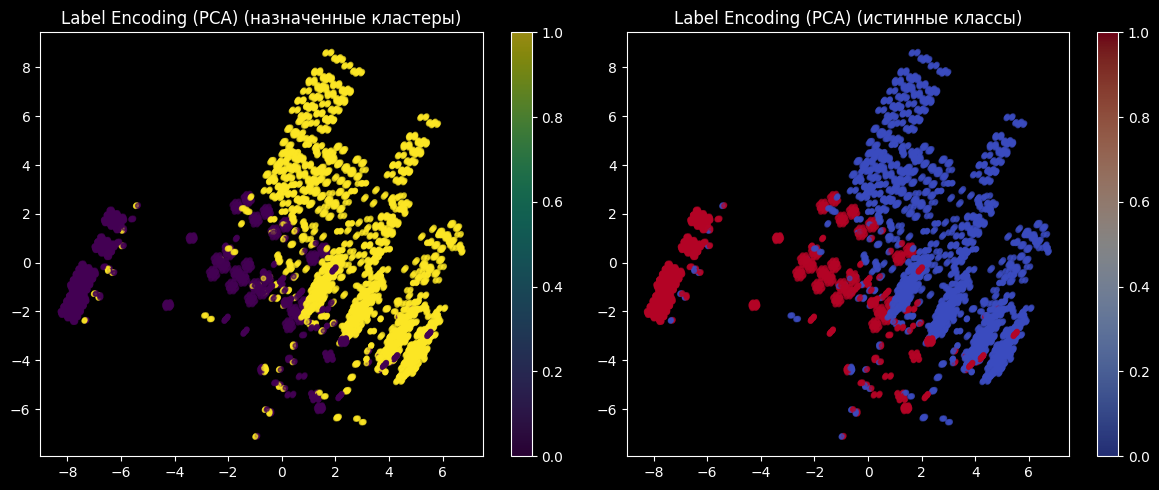

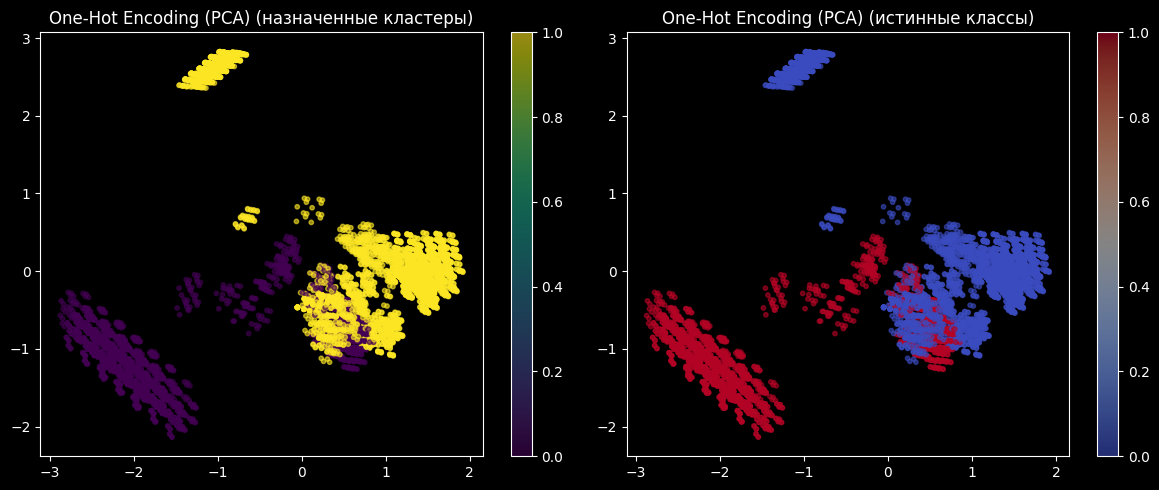

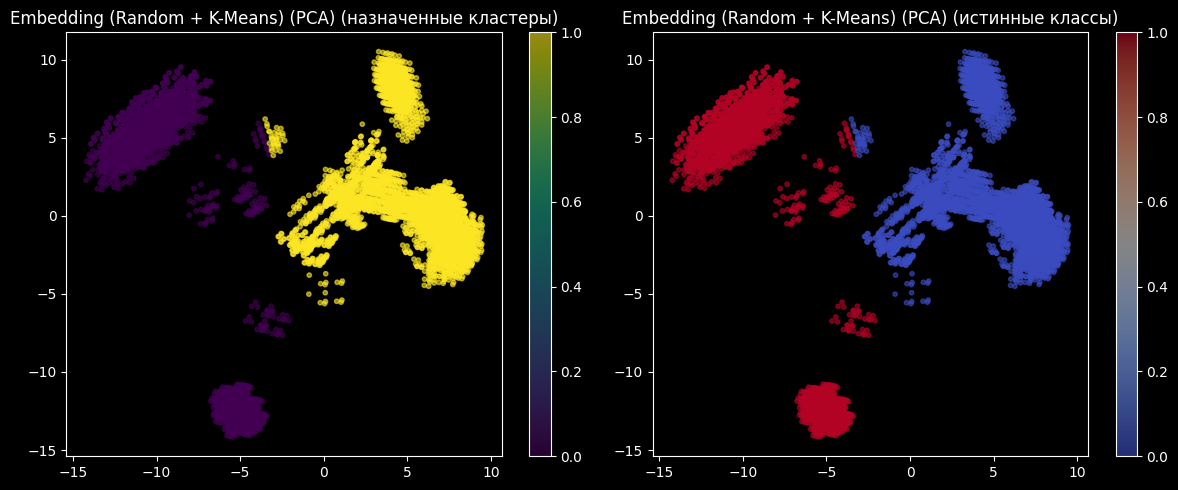

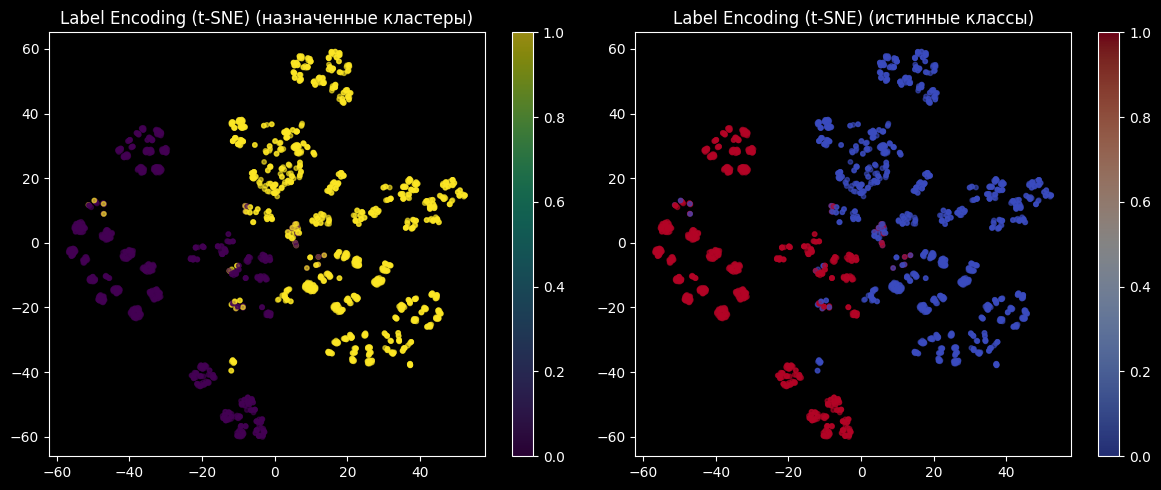

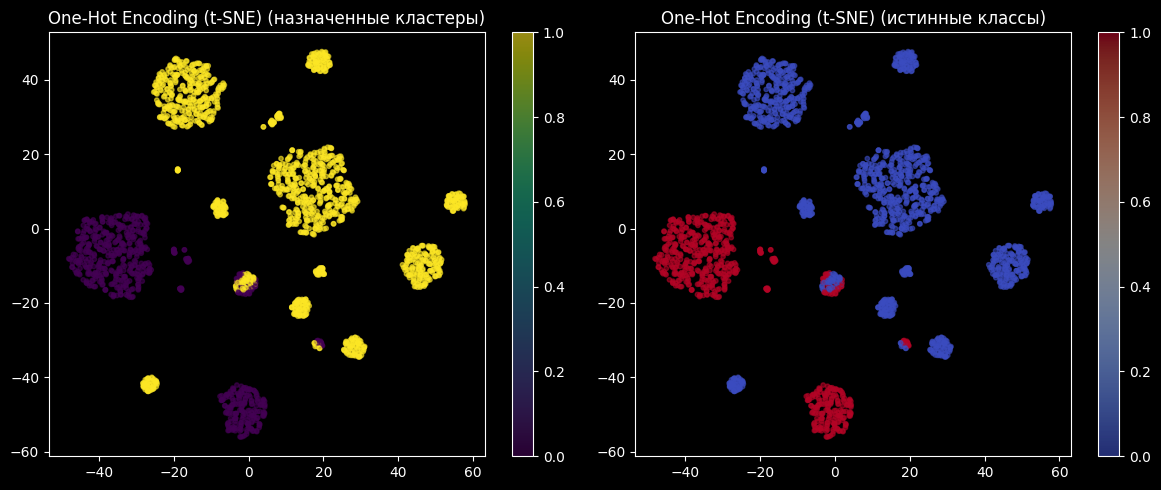

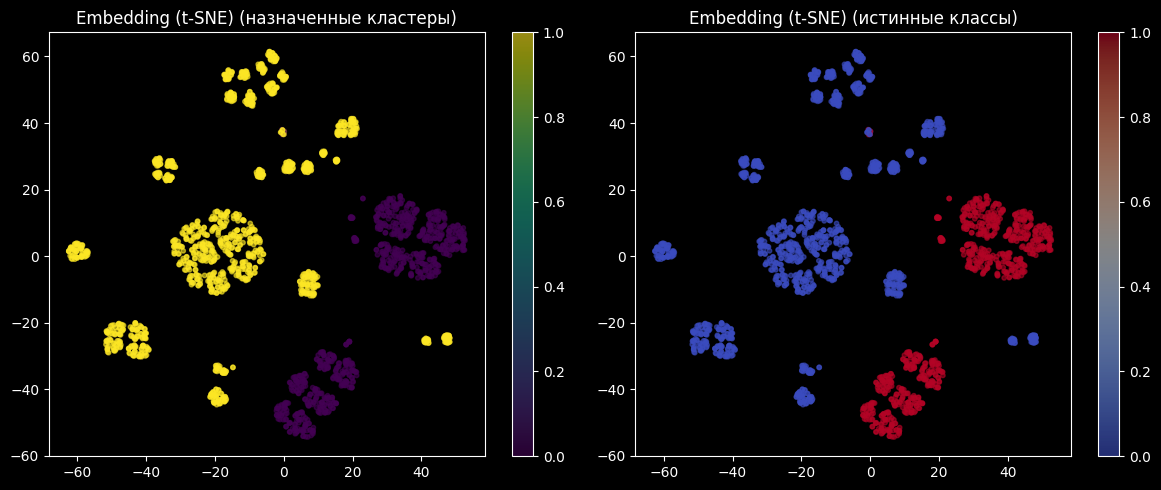

In [86]:
#преобразуем в числовой вид
pca = PCA(n_components=2, random_state=0)

#Label
X_label_pca = pca.fit_transform(X_label_np.astype(float))
plot_clusters(X_label_pca, labels_label, "Label Encoding (PCA)",
              y_true.values, y_pred_label_mapped)

#One-Hot
X_onehot_pca = pca.fit_transform(X_onehot)
plot_clusters(X_onehot_pca, labels_oh, "One-Hot Encoding (PCA)",
              y_true.values, y_pred_oh_mapped)

#Embedding
X_embed_pca = pca.fit_transform(X_embed_scaled)
plot_clusters(X_embed_pca, labels_embed, "Embedding (Random + K-Means) (PCA)",
              y_true.values, y_pred_embed_mapped)

# t-SNE
tsne = TSNE(n_components=2, random_state=0, perplexity=30)

#для ускорения ~2000
idx_sample = np.random.choice(len(y_true), 2000, replace=False)

#Label
X_label_tsne = tsne.fit_transform(X_label_np[idx_sample].astype(float))
plot_clusters(X_label_tsne, labels_label[idx_sample], "Label Encoding (t-SNE)",
              y_true.values[idx_sample], y_pred_label_mapped[idx_sample])

#One-Hot
X_onehot_tsne = tsne.fit_transform(X_onehot[idx_sample])
plot_clusters(X_onehot_tsne, labels_oh[idx_sample], "One-Hot Encoding (t-SNE)",
              y_true.values[idx_sample], y_pred_oh_mapped[idx_sample])

#Embedding
X_embed_tsne = tsne.fit_transform(X_embed_scaled[idx_sample])
plot_clusters(X_embed_tsne, labels_embed[idx_sample], "Embedding (t-SNE)",
              y_true.values[idx_sample], y_pred_embed_mapped[idx_sample])


In [87]:
results_df = pd.DataFrame([metrics_label, metrics_oh, metrics_embed],
                          index=['Label Encoding', 'One-Hot Encoding', 'Embedding (Random)'])
results_df['Accuracy'] = [acc_label, acc_oh, acc_embed]
results_df = results_df[['Accuracy', 'Sensitivity', 'Specificity', 'ARI', 'NMI']]
results_df


,Accuracy,Sensitivity,Specificity,ARI,NMI
Label Encoding,0.567701,0.471910,0.656844,0.018172,0.012584
One-Hot Encoding,0.605613,0.451481,0.749049,0.044395,0.033320
Embedding (Random),0.891679,0.791624,0.984791,0.613580,0.559898


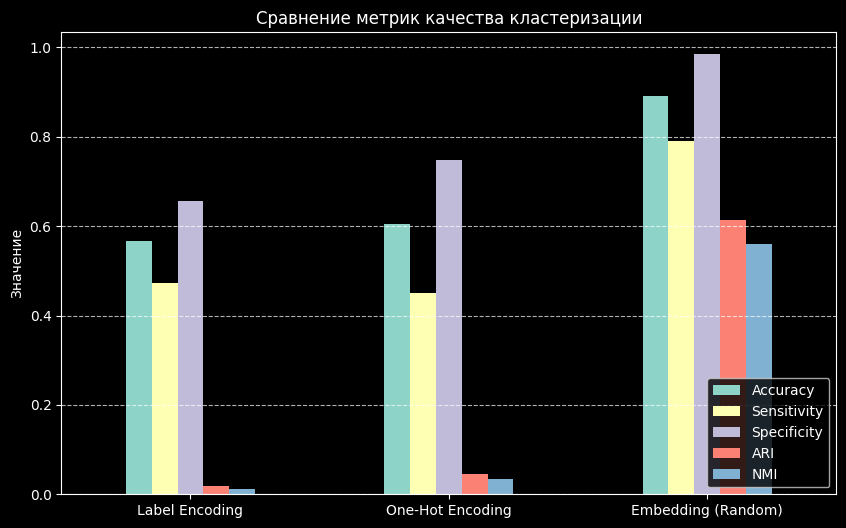

In [88]:
results_df.plot(kind='bar', figsize=(10,6))
plt.title('Сравнение метрик качества кластеризации')
plt.ylabel('Значение')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
